# Secondary $\nu_\tau$ flux from neutrino interactions in the rock

The forward neutrino beam contains no $\nu_\tau$ at production ($\mu$ decay), but the
primary $\bar\nu_\mu/\nu_e$ flux **makes its own** $\nu_\tau$'s by charm production in
the rock upstream of the detector:

$$\nu\, N \to \ell\, c\, X, \qquad c \to D_s \;(f_{D_s} \simeq 8\%), \qquad
D_s \to \tau\, \nu_\tau \;({\rm BR} = 5.3\%), \qquad \tau \to \nu_\tau X,$$

two $\nu_\tau$'s per chain: a **soft one from the $D_s$ decay**
($\tau$ takes $m_\tau^2/m_{D_s}^2 = 0.82$ of the $D_s$) and a **harder one from the
$\tau$ decay** ($\langle E \rangle \simeq 0.4 E_\tau$). Both decays are prompt
($\gamma c\tau \sim$ cm $\ll$ interaction length), so the chain is local.

Estimate ingredients (`nutau_secondary.py`, all knobs exposed): data-driven
$\sigma_{\rm charm}$ from the MINT CC tables; $E_{D_s} = \langle y\rangle \langle z\rangle
E_\nu \simeq 0.26\, E_\nu$; exact flat two-body kernel for $D_s \to \tau\nu$ and a flat
$[0, 0.8\,E_\tau]$ kernel for the $\tau$ decay; and — crucially — a **Gaussian-cone
angular acceptance** per production depth,
$\theta_s \simeq p_T^{\rm eff}/E_{\nu_\tau}$ with $p_T^{\rm eff} = 0.7$ GeV: the
secondary is not collinear, and this suppresses the soft component from far-upstream
production by $\sim 25\times$ (validated below against the collinear limit).

Neglected: $D^\pm/D^0 \to \tau\nu$ (~7% extra), $B$ mesons, secondary attenuation,
$\tau$ energy loss, and the $\mu^-$ beam (which would double everything).

In [52]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt

import mint
mint.xsecs.use_backend("ct18")   # PDF-consistent LO CT18NNLO cross sections
from mint import const
from mint import detector_tools as dt
from mint import plot_tools as pt
from mint.MuC import MuDecaySimulator

from mint import xsecs
import nutau_secondary as nts

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Primary flux through the detector face at 5 km

In [53]:
ring, sims, injections_per_year = mint.examples.both_beams(n_evals=5e5)
sim, sim_nue = sims["numubar"], sims["nue"]

det = mint.detectors.load("benchmark_5km")
DIST, DET_R, GAP = det.dist, det.radius, det.gap
DET_L = det.fiducial_length          # active gas = the decay volume
Lss_half = det.rock_start
gas, TARGET_MAT, rock = det.gas, det.vertex_mat, det.rock
TARGET_THICK_TOT = det.Z_VTX1 - det.Z_VTX0

def flux_at(s, D=DIST):
    E_, w_, _ = det.flux_with_chords(s, sign=+1, exposure=injections_per_year)
    return E_, w_

Ec_mub, W_mub = dt.bin_flux(*flux_at(sim))
Ec_nue, W_nue = dt.bin_flux(*flux_at(sim_nue))
print(f"primaries through the face: numubar {W_mub.sum():.3e} /yr | nue {W_nue.sum():.3e} /yr")

# charm-chain rate in the rock (before angular acceptance)
col_rock = rock.N * det.rock_column   # nucleons/cm^2 along the column
for Ec, W, lab in [(Ec_mub, W_mub, "numubar"), (Ec_nue, W_nue, "nue")]:
    n_charm = np.sum(W * nts.sigma_charm_cc(Ec, lab)) * col_rock
    print(f"{lab}: charm-CC events in the rock column: {n_charm:.3e} /yr "
          f"-> {n_charm * nts.F_DS * nts.BR_DS_TAUNU:.3e} D_s -> tau nu chains/yr")

/Users/mhostert/Repos/MINT/mint/MuC.py:442: UserWarning: The lattice covers only 14.6% of the machine (arc length 1.465e+05 cm of total_circumference 1e+06 cm). Muon decays are placed on the covered section only; muon travel times account for propagation through the full machine.
  warnings.warn(


primaries through the face: numubar 2.223e+18 /yr | nue 2.207e+18 /yr
numubar: charm-CC events in the rock column: 1.649e+12 /yr -> 7.018e+09 D_s -> tau nu chains/yr
nue: charm-CC events in the rock column: 1.888e+12 /yr -> 8.034e+09 D_s -> tau nu chains/yr


## 2. Ingredients: charm fraction and the angular-acceptance factor

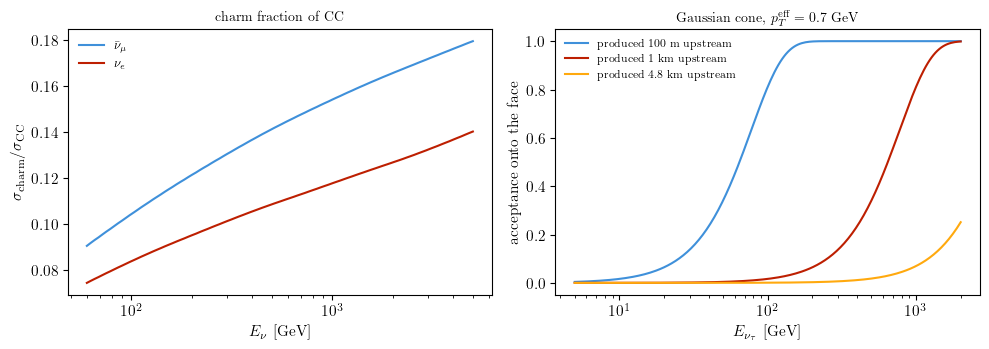

In [54]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3.6))

Egrid = np.geomspace(60, 5e3, 100)
ax[0].plot(Egrid, nts.sigma_charm_cc(Egrid, "numubar") / xsecs.sigma_CC(Egrid, "numubar"),
           label=r"$\bar\nu_\mu$")
ax[0].plot(Egrid, nts.sigma_charm_cc(Egrid, "nue") / xsecs.sigma_CC(Egrid, "nue"),
           label=r"$\nu_e$")
ax[0].set_xscale("log")
ax[0].set_xlabel(r"$E_\nu$ [GeV]")
ax[0].set_ylabel(r"$\sigma_{\rm charm}/\sigma_{\rm CC}$")
ax[0].legend(frameon=False, fontsize=9)
ax[0].set_title("charm fraction of CC", fontsize=10)

E_nt = np.geomspace(5, 2000, 200)
for L_rem, lab in [(100e2, "100 m"), (1000e2, "1 km"), (4800e2, "4.8 km")]:
    ax[1].plot(E_nt, nts._cone_acceptance(E_nt, L_rem, DET_R), label=f"produced {lab} upstream")
ax[1].set_xscale("log")
ax[1].set_xlabel(r"$E_{\nu_\tau}$ [GeV]")
ax[1].set_ylabel("acceptance onto the face")
ax[1].legend(frameon=False, fontsize=8)
ax[1].set_title(r"Gaussian cone, $p_T^{\rm eff} = 0.7$ GeV", fontsize=10)
plt.tight_layout()

## 3. The secondary $\nu_\tau$ flux

numubar-induced: D_s-line 1.753e+08 | tau-line 7.593e+08 nu_tau/yr through the face
nue-induced: D_s-line 1.648e+08 | tau-line 7.488e+08 nu_tau/yr through the face
TOTAL secondary nu_tau through the face: 1.848e+09 /yr


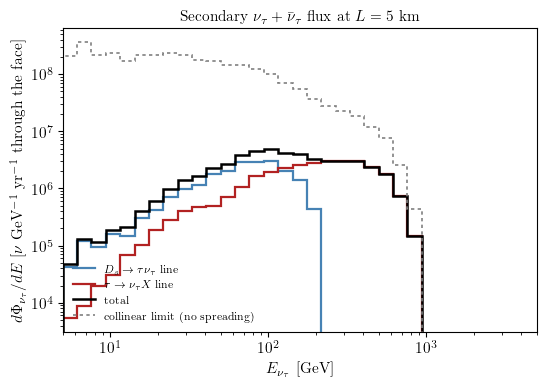

In [55]:
Enu_edges = np.geomspace(5, 5000, 34)
Enu_c = np.sqrt(Enu_edges[1:] * Enu_edges[:-1])
dE = np.diff(Enu_edges)

components = {}
for Ec, W, lab in [(Ec_mub, W_mub, "numubar"), (Ec_nue, W_nue, "nue")]:
    f1, f2 = nts.nutau_flux_spectrum(
        Ec, W, lab, rock, Lss_half, DIST - GAP, DIST, DET_R, Enu_edges)
    components[lab] = (f1, f2)
    print(f"{lab}-induced: D_s-line {f1.sum():.3e} | tau-line {f2.sum():.3e} nu_tau/yr through the face")

f1_tot = sum(c[0] for c in components.values())
f2_tot = sum(c[1] for c in components.values())
flux_tot = f1_tot + f2_tot
print(f"TOTAL secondary nu_tau through the face: {flux_tot.sum():.3e} /yr")

# collinear limit (upper bound, no angular spreading)
f1c, f2c = 0, 0
for Ec, W, lab in [(Ec_mub, W_mub, "numubar"), (Ec_nue, W_nue, "nue")]:
    a, b = nts.nutau_flux_spectrum(Ec, W, lab, rock, Lss_half, DIST - GAP, DIST,
                                   DET_R, Enu_edges, pt_eff=1e-9)
    f1c, f2c = f1c + a, f2c + b

fig, ax = pt.std_fig(figsize=(6, 4))
ax.stairs(f1_tot / dE, Enu_edges, color="steelblue", lw=1.6, label=r"$D_s \to \tau\nu_\tau$ line")
ax.stairs(f2_tot / dE, Enu_edges, color="firebrick", lw=1.6, label=r"$\tau \to \nu_\tau X$ line")
ax.stairs(flux_tot / dE, Enu_edges, color="black", lw=1.8, label="total")
ax.stairs((f1c + f2c) / dE, Enu_edges, color="gray", lw=1.2, ls=(0, (2, 2)),
          label="collinear limit (no spreading)")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(Enu_edges[0], Enu_edges[-1])
ax.set_xlabel(r"$E_{\nu_\tau}$ [GeV]")
ax.set_ylabel(r"$d\Phi_{\nu_\tau}/dE$ [$\nu$ GeV$^{-1}$ yr$^{-1}$ through the face]")
ax.set_title(r"Secondary $\nu_\tau + \bar\nu_\tau$ flux at $L = 5$ km", fontsize=11)
ax.legend(frameon=False, fontsize=8, loc="lower left")
fig.savefig("plots/nutau_secondary_flux.pdf", bbox_inches="tight", dpi=300)

## 4. $\nu_\tau$ CC events in the detector ($\tau$ appearance)

detector column: 43 g/cm^2 equivalent
nu_tau CC events/yr in the detector: 0.07 (collinear upper bound 0.5)
scalings: x2 with the mu- beam; linear in detector column density


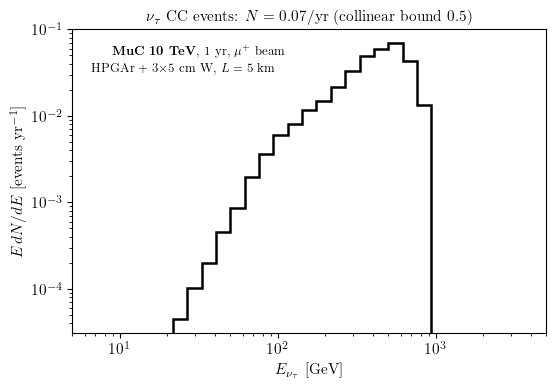

In [56]:
# detector nucleon column: 10 m of 10-bar GAr + 3 x 5 cm W slabs
col_det = det.nucleon_column()      # signal volume: vertex tracker + gas
print(f"detector column: {col_det * 1.66054e-24:.0f} g/cm^2 equivalent")

dN_dE = flux_tot * nts.sigma_nutau_cc_avg(Enu_c) * col_det / dE
N_tot = np.sum(dN_dE * dE)
N_coll = np.sum((f1c + f2c) * nts.sigma_nutau_cc_avg(Enu_c) * col_det)

fig, ax = pt.std_fig(figsize=(6, 4))
ax.stairs(dN_dE * Enu_c, Enu_edges, color="black", lw=1.8)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(Enu_edges[0], Enu_edges[-1])
ax.set_xlabel(r"$E_{\nu_\tau}$ [GeV]")
ax.set_ylabel(r"$E\, dN/dE$ [events yr$^{-1}$]")
ax.set_title(rf"$\nu_\tau$ CC events: $N = {N_tot:.2f}$/yr "
             rf"(collinear bound {N_coll:.1f})", fontsize=11)
ax.annotate(r"\textbf{MuC 10 TeV}, 1 yr, $\mu^+$ beam\\HPGAr + 3$\times$5 cm W, $L=5$ km",
            xy=(0.04, 0.95), xycoords="axes fraction", ha="left", va="top", fontsize=9,
            multialignment="left")
fig.savefig("plots/nutau_secondary_events.pdf", bbox_inches="tight", dpi=300)

print(f"nu_tau CC events/yr in the detector: {N_tot:.2f} (collinear upper bound {N_coll:.1f})")
print(f"scalings: x2 with the mu- beam; linear in detector column density")

## 5. Improved kinematics: dimuon-inspired MC

The kernel estimate above is upgraded to a full chain-kinematics Monte Carlo built from
the **standard neutrino-charm (dimuon) treatments**:

- LO charm production $d^2\sigma/d\xi\,dy$ with slow rescaling
  ($\xi = x(1 + m_c^2/Q^2)$, threshold factor $1 - m_c^2/2ME\xi$), $m_c = 1.70$ GeV and
  the strange-sea shape $xs(x) \propto (1-x)^{6.98} x^{-0.164}$ from the **CCFR NLO
  analysis** (Bazarko et al., hep-ex/9406007, Table 4);
- fragmentation $c \to D_s$ with the **Peterson function** ($\epsilon_P = 0.20$) and a
  **Gaussian $p_T$** of the hadron about the quark direction,
  $dn/dp_T^2 \propto e^{-\beta p_T^2}$ with $\beta = 1.21$ GeV$^{-2}$ (E531; the
  Gaussian smearing is the standard treatment, cf. Kretzer–Mason–Olness,
  hep-ph/0112191);
- the current-jet direction from the event kinematics,
  $\theta_W \simeq Q\sqrt{1-y}/(yE_\nu)$;
- **exact two-body** $D_s \to \tau\nu_\tau$, and $\tau \to \nu_\tau X$ resolved by
  channel (leptonic 35% with $dN/dx = 2x^2(3-2x)$; $\pi$, $\rho$(+other), $a_1$ as
  two-body; $\tau$ polarization neglected);
- hard geometric acceptance $\theta \cdot L_{\rm rem} < r_{\rm det}$ per sampled chain.

The normalization still comes from the data-driven $\sigma_{\rm charm}$ tables — the MC
only shapes the kinematics, so the threshold suppression is not double-counted.

numubar-induced (MC): D_s-line 4.096e+08 | tau-line 4.146e+08 nu_tau/yr
nue-induced (MC): D_s-line 4.159e+08 | tau-line 4.191e+08 nu_tau/yr
TOTAL (MC): 1.659e+09 nu_tau/yr through the face (kernel estimate: 1.848e+09)
nu_tau CC events/yr (MC kinematics): 0.05  (kernel: 0.07)


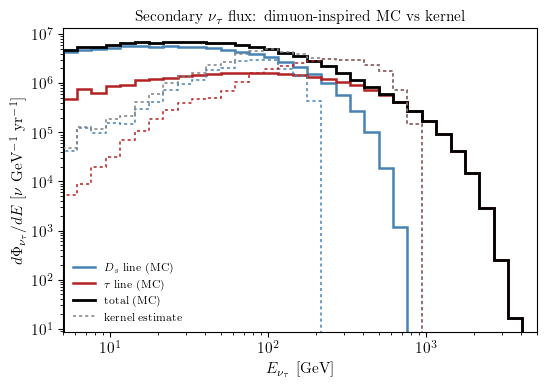

In [57]:
mc = {}
for Ec, W, lab in [(Ec_mub, W_mub, "numubar"), (Ec_nue, W_nue, "nue")]:
    f1m, f2m = nts.nutau_flux_spectrum_mc(
        Ec, W, lab, rock, Lss_half, DIST - GAP, DIST, DET_R, Enu_edges,
        n_mc=600_000, rng=1)
    mc[lab] = (f1m, f2m)
    print(f"{lab}-induced (MC): D_s-line {f1m.sum():.3e} | tau-line {f2m.sum():.3e} nu_tau/yr")

f1_mc = sum(c[0] for c in mc.values())
f2_mc = sum(c[1] for c in mc.values())
flux_mc = f1_mc + f2_mc
print(f"TOTAL (MC): {flux_mc.sum():.3e} nu_tau/yr through the face "
      f"(kernel estimate: {flux_tot.sum():.3e})")

fig, ax = pt.std_fig(figsize=(6, 4))
ax.stairs(f1_mc / dE, Enu_edges, color="steelblue", lw=1.8, label=r"$D_s$ line (MC)")
ax.stairs(f2_mc / dE, Enu_edges, color="firebrick", lw=1.8, label=r"$\tau$ line (MC)")
ax.stairs(flux_mc / dE, Enu_edges, color="black", lw=2.0, label="total (MC)")
ax.stairs(f1_tot / dE, Enu_edges, color="steelblue", lw=1.1, ls=(0, (2, 2)))
ax.stairs(f2_tot / dE, Enu_edges, color="firebrick", lw=1.1, ls=(0, (2, 2)))
ax.stairs(flux_tot / dE, Enu_edges, color="gray", lw=1.1, ls=(0, (2, 2)),
          label="kernel estimate")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(Enu_edges[0], Enu_edges[-1])
ax.set_xlabel(r"$E_{\nu_\tau}$ [GeV]")
ax.set_ylabel(r"$d\Phi_{\nu_\tau}/dE$ [$\nu$ GeV$^{-1}$ yr$^{-1}$]")
ax.set_title(r"Secondary $\nu_\tau$ flux: dimuon-inspired MC vs kernel", fontsize=11)
ax.legend(frameon=False, fontsize=8, loc="lower left")
fig.savefig("plots/nutau_secondary_flux_mc.pdf", bbox_inches="tight", dpi=300)

# events with the MC spectrum
dN_dE_mc = flux_mc * nts.sigma_nutau_cc_avg(Enu_c) * col_det / dE
N_mc = np.sum(dN_dE_mc * dE)
print(f"nu_tau CC events/yr (MC kinematics): {N_mc:.2f}  (kernel: {N_tot:.2f})")

### Tau polarization

The $\tau$'s in both chains are **fully polarized at production** and the decay spectra
carry the imprint:

- **$D_s \to \tau\nu$**: angular momentum in the pseudoscalar two-body decay forces the
  $\tau^-$ into helicity $+1$ in the $D_s$ frame (*exactly*, for massless $\nu$ — the
  "wrong-helicity" configuration is the only one). The **lab** longitudinal polarization follows from exact spin
  transport (spin-4-vector boosted with the parent; boost-independent for
  $\gamma \gtrsim 10$):
  $P = (\cos\theta^*_\tau + \beta^*)/(1 + \beta^*\cos\theta^*_\tau)$ with
  $\beta^* = (M_P^2 - m_\tau^2)/(M_P^2 + m_\tau^2) \simeq 0.10$ ($D_s$) — the
  relativistic addition of the helicity axis; it reduces to the naive
  $\cos\theta^*_\tau$ as $\beta^* \to 0$ and shifts $\langle P\rangle$ from 0 to
  $\approx \beta^*$.
- **Inverse tau decay**: $P = -1$ (left-handed, massless V–A limit; partial
  depolarization near threshold neglected for this $\sim$5% source).

Rest-frame distributions: two-body channels $\tfrac{1}{2}(1 + \alpha_\nu P\cos\theta)$
with $\alpha_\nu = -1$ ($\pi$), $-0.449$ ($\rho$), $+0.003$ ($a_1$), from
$\alpha_h = (m_\tau^2 - 2m_h^2)/(m_\tau^2 + 2m_h^2)$; leptonic
$x^2[(3-2x) + P(1-2x)\cos\theta]$. Both are validated below against the analytic lab
spectra — the leptonic one reproduces the standard polynomials
$g_0(y) + P g_1(y) = (\tfrac{5}{3} - 3y^2 + \tfrac{4}{3}y^3) + P(\tfrac{1}{3} - 3y^2 +
\tfrac{8}{3}y^3)$. $\tau^+$ vs $\tau^-$: both $P$ and $\alpha$ flip under CP, so one
convention covers both chains.

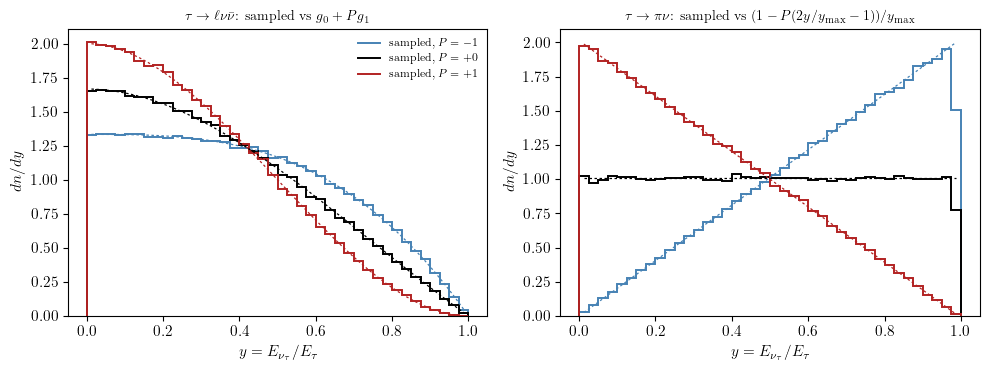

In [58]:
# Validation: sampled lab spectra vs analytic polarized forms, P = -1, 0, +1
rngv = np.random.default_rng(11)
E_ref = np.full(300_000, 1000.0)
yb = np.linspace(0, 1, 41)
yc = 0.5 * (yb[1:] + yb[:-1])
dy = np.diff(yb)
g0 = lambda y: 5/3 - 3*y**2 + 4*y**3/3
g1 = lambda y: 1/3 - 3*y**2 + 8*y**3/3
r_pi = (nts.M_PI / nts.M_TAU) ** 2

fig, ax = plt.subplots(1, 2, figsize=(10, 3.8))
cols = {-1.0: "steelblue", 0.0: "black", 1.0: "firebrick"}
for Pv in (-1.0, 0.0, 1.0):
    E, _ = nts._sample_tau_decay(E_ref, rngv, P=Pv*np.ones_like(E_ref), force_channel="lep")
    h = np.histogram(E / 1000.0, bins=yb)[0] / len(E) / dy
    ax[0].stairs(h, yb, color=cols[Pv], lw=1.4, label=rf"sampled, $P = {Pv:+.0f}$")
    ax[0].plot(yc, g0(yc) + Pv * g1(yc), color=cols[Pv], lw=0.9, ls=(0, (2, 2)))

    E, _ = nts._sample_tau_decay(E_ref, rngv, P=Pv*np.ones_like(E_ref), force_channel="pi")
    h = np.histogram(E / 1000.0, bins=yb)[0] / len(E) / dy
    ax[1].stairs(h, yb, color=cols[Pv], lw=1.4)
    ymax = 1 - r_pi
    ana = np.where(yc < ymax, (1 - Pv * (2 * yc / ymax - 1)) / ymax, 0)
    ax[1].plot(yc, ana, color=cols[Pv], lw=0.9, ls=(0, (2, 2)))

ax[0].set_title(r"$\tau \to \ell \nu\bar\nu$: sampled vs $g_0 + P g_1$", fontsize=10)
ax[1].set_title(r"$\tau \to \pi\nu$: sampled vs $(1 - P(2y/y_{\max} - 1))/y_{\max}$", fontsize=10)
for a in ax:
    a.set_xlabel(r"$y = E_{\nu_\tau}/E_\tau$")
    a.set_ylabel(r"$dn/dy$")
ax[0].legend(frameon=False, fontsize=8)
plt.tight_layout()
fig.savefig("plots/nutau_tau_polarization_validation.pdf", bbox_inches="tight", dpi=300)

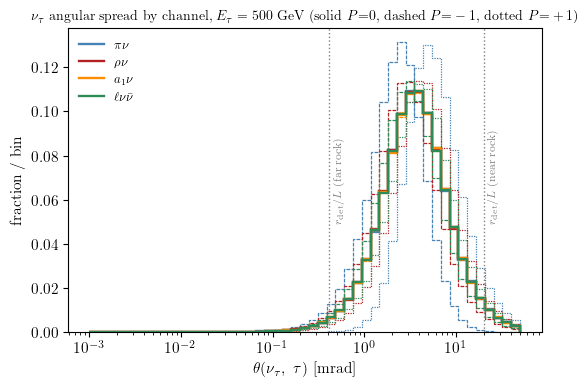

In [59]:
# Angular spread of the decay nu_tau wrt the tau direction, per channel
# (E_tau = 500 GeV; solid P = 0, thin dashed P = -1 / dotted P = +1)
E_ref2 = np.full(300_000, 500.0)
th_edges = np.geomspace(1e-3, 50, 50)   # mrad
chan_cols = {"pi": "steelblue", "rho": "firebrick", "a1": "darkorange", "lep": "seagreen"}
chan_labs = {"pi": r"$\pi\nu$", "rho": r"$\rho\nu$", "a1": r"$a_1\nu$",
             "lep": r"$\ell\nu\bar\nu$"}

fig, ax = pt.std_fig(figsize=(6, 4))
for chn, c in chan_cols.items():
    for Pv, ls, lw in ((0.0, "-", 1.7), (-1.0, (0, (3, 1)), 0.9), (1.0, (0, (1, 1)), 0.9)):
        _, th = nts._sample_tau_decay(E_ref2, rngv, P=Pv*np.ones_like(E_ref2), force_channel=chn)
        h = np.histogram(th * 1e3, bins=th_edges)[0] / len(th)
        ax.stairs(h, th_edges, color=c, lw=lw, ls=ls,
                  label=chan_labs[chn] if Pv == 0 else None)
ax.axvline(200.0 / 4.8e5 * 1e3, color="gray", ls=":", lw=1.0)
ax.annotate(r"$r_{\rm det}/L$ (far rock)", xy=(200.0 / 4.8e5 * 1e3 * 1.1, 0.05),
            fontsize=8, color="gray", rotation=90)
ax.axvline(200.0 / 1e4 * 1e3, color="gray", ls=":", lw=1.0)
ax.annotate(r"$r_{\rm det}/L$ (near rock)", xy=(200.0 / 1e4 * 1e3 * 1.1, 0.05),
            fontsize=8, color="gray", rotation=90)
ax.set_xscale("log")
ax.set_xlabel(r"$\theta(\nu_\tau,\ \tau)$ [mrad]")
ax.set_ylabel("fraction / bin")
ax.set_title(r"$\nu_\tau$ angular spread by channel, $E_\tau = 500$ GeV "
             r"(solid $P{=}0$, dashed $P{=}-1$, dotted $P{=}+1$)", fontsize=10)
ax.legend(frameon=False, fontsize=9)
fig.savefig("plots/nutau_angular_spread_channels.pdf", bbox_inches="tight", dpi=300)

## 6. Adding the $\mu^-$ beam and inverse tau decay

The $\mu^-$ beam ($\nu_\mu + \bar\nu_e$, detector 5 km **upstream**, mirrored geometry)
contributes two ways:

1. **Charm chains**, identical to Section 5 with the per-flavor cross sections
   ($\nu_\mu$: $\sigma^{\rm charm}_{\nu}$ off $s, d$; $\bar\nu_e$:
   $\sigma^{\rm charm}_{\bar\nu}$ off $\bar s, \bar d$).
2. **Inverse tau decay**: $\bar\nu_e\, e^- \to \tau^-\, \bar\nu_\tau$ — s-channel $W$
   annihilation on the **electrons of the rock**, the reverse of
   $\tau^- \to \nu_\tau e^- \bar\nu_e$. Only the $\bar\nu_e$ flux can do this, and the
   threshold $E_\nu > m_\tau^2/2m_e \simeq 3.09$ TeV selects the multi-TeV Michel tail
   (about half the $\bar\nu_e$ flux). Each event yields **two** tau-flavored neutrinos:
   the prompt $\bar\nu_\tau$ from the vertex and the $\nu_\tau$ from the $\tau$ decay.
   The cross section is `mint.xsecs.inverse_lepton_decay_sigma` (V–A with mass
   corrections, $\sim 4\times 10^{-38}$ cm$^2$ near 5 TeV); the kinematics are exact
   two-body with the V–A angular weight
   $|M|^2 \propto (k_{\bar\nu_e} \cdot k_{\bar\nu_\tau})(p_e \cdot p_\tau)$, followed by
   the channel-resolved $\tau$ decay of Section 5. The CM boost is enormous
   ($\gamma \sim E_\nu/\sqrt{s} \sim 2000$), so the chain is nearly collinear and the
   acceptance is $\approx 1$ even from far-upstream production — unlike the charm
   chains, the rock column contributes at full strength.

In [60]:
# mu- beam: numu + nuebar via exact reweighting, placed counter-clockwise;
# detector 5 km upstream (mirrored geometry -> same distances by symmetry)
sim_numu, sim_nueb = sims["numu"], sims["nuebar"]

def flux_at_upstream(s):
    E_, w_, _ = det.flux_with_chords(s, sign=-1, exposure=injections_per_year)
    return E_, w_

Ec_mu, W_mu = dt.bin_flux(*flux_at_upstream(sim_numu))
Ec_eb, W_eb = dt.bin_flux(*flux_at_upstream(sim_nueb))
print(f"upstream primaries: numu {W_mu.sum():.3e} /yr | nuebar {W_eb.sum():.3e} /yr")

# charm chains at the upstream detector
mc_m = {}
for Ec_, W_, lab in [(Ec_mu, W_mu, "numu"), (Ec_eb, W_eb, "nuebar")]:
    a, b = nts.nutau_flux_spectrum_mc(Ec_, W_, lab, rock, Lss_half, DIST - GAP,
                                      DIST, DET_R, Enu_edges, n_mc=600_000, rng=2)
    mc_m[lab] = (a, b)
    print(f"{lab} charm chains (MC): {a.sum() + b.sum():.3e} nu_tau/yr")
charm_m = sum(a + b for a, b in mc_m.values())

# inverse tau decay on the electrons of the rock (nuebar flux only)
itd3, itd2 = nts.nutau_flux_spectrum_itd_mc(Ec_eb, W_eb, rock, Lss_half, DIST - GAP,
                                            DIST, DET_R, Enu_edges, n_mc=400_000, rng=3)
itd_tot = itd3 + itd2
print(f"ITD: prompt nubar_tau {itd3.sum():.3e} | tau-line {itd2.sum():.3e} nu_tau/yr")

upstream primaries: numu 2.214e+18 /yr | nuebar 2.224e+18 /yr
numu charm chains (MC): 1.111e+09 nu_tau/yr
nuebar charm chains (MC): 6.354e+08 nu_tau/yr
ITD: prompt nubar_tau 1.647e+07 | tau-line 3.818e+07 nu_tau/yr


nu_tau CC events/yr, downstream det. (mu+ charm):        0.05
nu_tau CC events/yr, upstream det.   (mu- charm):        0.06
nu_tau CC events/yr, upstream det.   (inverse tau decay): 0.01
GRAND TOTAL (both detectors):                            0.12 /yr


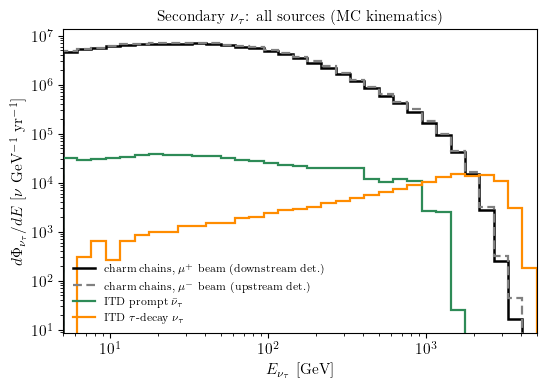

In [61]:
# combined picture: both beams/detectors and all sources
fig, ax = pt.std_fig(figsize=(6, 4))
ax.stairs(flux_mc / dE, Enu_edges, color="black", lw=1.8,
          label=r"charm chains, $\mu^+$ beam (downstream det.)")
ax.stairs(charm_m / dE, Enu_edges, color="gray", lw=1.6, ls=(0, (4, 2)),
          label=r"charm chains, $\mu^-$ beam (upstream det.)")
ax.stairs(itd3 / dE, Enu_edges, color="seagreen", lw=1.6,
          label=r"ITD prompt $\bar\nu_\tau$")
ax.stairs(itd2 / dE, Enu_edges, color="darkorange", lw=1.6,
          label=r"ITD $\tau$-decay $\nu_\tau$")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(Enu_edges[0], Enu_edges[-1])
ax.set_xlabel(r"$E_{\nu_\tau}$ [GeV]")
ax.set_ylabel(r"$d\Phi_{\nu_\tau}/dE$ [$\nu$ GeV$^{-1}$ yr$^{-1}$]")
ax.set_title(r"Secondary $\nu_\tau$: all sources (MC kinematics)", fontsize=11)
ax.legend(frameon=False, fontsize=8, loc="lower left")
fig.savefig("plots/nutau_secondary_full.pdf", bbox_inches="tight", dpi=300)

# non-isoscalar detector-column correction, nu/nubar averaged (the +5%/-4%
# W-column shifts nearly cancel for a nu+nubar-summed flux: net ~+0.5%)
_cc_cor_avg = 0.5 * (det.cc_correction(Enu_c, "nutau")
                     + det.cc_correction(Enu_c, "nutaubar"))

def events(flux):
    return float(np.sum(flux * nts.sigma_nutau_cc_avg(Enu_c) * _cc_cor_avg * col_det))

N_charm_m = events(charm_m)
N_itd = events(itd_tot)
print(f"nu_tau CC events/yr, downstream det. (mu+ charm):        {N_mc:.2f}")
print(f"nu_tau CC events/yr, upstream det.   (mu- charm):        {N_charm_m:.2f}")
print(f"nu_tau CC events/yr, upstream det.   (inverse tau decay): {N_itd:.2f}")
print(f"GRAND TOTAL (both detectors):                            {N_mc + N_charm_m + N_itd:.2f} /yr")

## 7. Resonant $\bar\nu_e\, e^- \to D_s^{*-}$ and $D^{*-}$

Following Brdar–de Gouvêa–Machado–Plestid (arXiv:2112.03283): the $\bar\nu_e$
flux can form charged **vector mesons in the $s$-channel on the rock
electrons** — the low-energy analog of the Glashow resonance. The only
resonances that cascade to $\nu_\tau$ are the vector charm mesons:

- $D_s^{*-}$, formed at $E_{\rm res} = (M^2-m_e^2)/2m_e = 4.37$ TeV:
  $D_s^{*-} \to D_s^-\,\gamma/\pi^0$ (Br $\simeq 1$) then
  $D_s^- \to \tau^-\bar\nu_\tau$ (5.3%) — two $\nu_\tau$ per chain;
- $D^{*-}$ at 3.95 TeV: $D^{*-}\to D^-\,\pi^0/\gamma$ (32%) then
  $D^-\to\tau^-\bar\nu_\tau$ (0.12%) — doubly suppressed ($|V_{cd}|^2$
  formation and the small leptonic BR).

The total widths are keV-scale, so the resonance is a $\sim 10^{-4}$ GeV
spike in $E_\nu$ and the rate is computed in the **narrow-width
approximation**, $\int\sigma\,dE = 24\pi^2\,\Gamma_{e\nu}{\rm Br}_{\rm fi}/
(2 m_e M)$ with $\Gamma_{e\nu} = G_F^2 f^2 M^3 |V_{\rm CKM}|^2/12\pi$
(paper Eq. 2; the total width cancels — validated against the direct
Breit–Wigner integral to $10^{-4}$). Only $d\Phi/dE$ at $E_{\rm res}$
matters: the last few hundred GeV of the Michel tail. Formation on an
electron at rest is exactly collinear and the chain stays within
$\sim 0.5$ mrad — near-unit acceptance, like ITD. Pseudoscalar formation
($D^-_{(s)}$ directly) is chirality-suppressed by $m_e^2/M^2$, and the
direct $D_s^{*-}\to\tau^-\bar\nu_\tau$ mode has ${\rm Br}\sim 4\times
10^{-6}$ (the EM width dominates); both are neglected.

Ds*: E_res = 4.37 TeV | int sigma dE = 1.04e-34 cm^2 GeV | dPhi/dE(E_res) = 4.14e+13 nu/yr/GeV
     chains 8.640e+07 /yr | nu_tau through the face 1.019e+08 /yr | CC events 0.014 /yr
D*: E_res = 3.95 TeV | int sigma dE = 1.30e-36 cm^2 GeV | dPhi/dE(E_res) = 1.03e+14 nu/yr/GeV
     chains 6.066e+04 /yr | nu_tau through the face 6.950e+04 /yr | CC events 0.000 /yr

resonance nu_tau CC events/yr (upstream det.): 0.014
UPDATED GRAND TOTAL (both detectors): 0.14 /yr


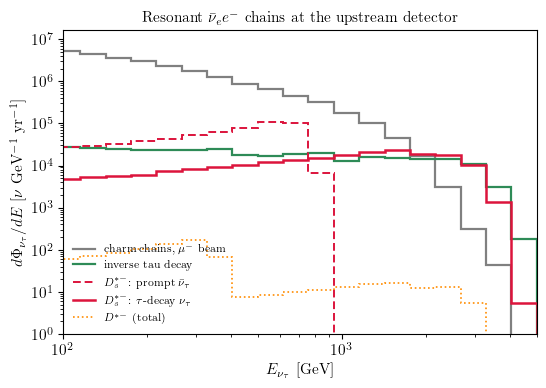

In [62]:
# resonant formation on the rock electrons (NWA line strengths from the module)
E_eb_raw, w_eb_raw = flux_at_upstream(sim_nueb)

res = {}
for which in ("Ds*", "D*"):
    E_res, S = nts.resonance_line(which)
    br = nts._RESONANCES[which][5]
    in_win = np.abs(E_eb_raw - E_res) < 250.0
    dphi = w_eb_raw[in_win].sum() / 500.0
    a, b = nts.nutau_flux_spectrum_res_mc(E_eb_raw, w_eb_raw, rock, Lss_half,
                                          DIST - GAP, DIST, DET_R, Enu_edges,
                                          which=which, n_mc=150_000, rng=12)
    res[which] = (a, b)
    n_ch = (rock.N * rock.Z / rock.A) * (DIST - GAP - Lss_half) * dphi * S * br
    print(f"{which}: E_res = {E_res/1e3:.2f} TeV | int sigma dE = {S:.2e} cm^2 GeV | "
          f"dPhi/dE(E_res) = {dphi:.2e} nu/yr/GeV")
    print(f"     chains {n_ch:.3e} /yr | nu_tau through the face {(a + b).sum():.3e} /yr "
          f"| CC events {events(a + b):.3f} /yr")
res_tot = sum(a + b for a, b in res.values())

# the multi-TeV tail: resonance vs the other upstream sources
fig, ax = pt.std_fig(figsize=(6, 4))
ax.stairs(charm_m / dE, Enu_edges, color="gray", lw=1.6,
          label=r"charm chains, $\mu^-$ beam")
ax.stairs(itd_tot / dE, Enu_edges, color="seagreen", lw=1.6,
          label="inverse tau decay")
a, b = res["Ds*"]
ax.stairs(a / dE, Enu_edges, color="crimson", lw=1.4, ls=(0, (4, 2)),
          label=r"$D_s^{*-}$: prompt $\bar\nu_\tau$")
ax.stairs(b / dE, Enu_edges, color="crimson", lw=1.8,
          label=r"$D_s^{*-}$: $\tau$-decay $\nu_\tau$")
ax.stairs(sum(res["D*"]) / dE, Enu_edges, color="darkorange", lw=1.2, ls=":",
          label=r"$D^{*-}$ (total)")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(1e2, Enu_edges[-1])
ax.set_ylim(1e0, None)
ax.set_xlabel(r"$E_{\nu_\tau}$ [GeV]")
ax.set_ylabel(r"$d\Phi_{\nu_\tau}/dE$ [$\nu$ GeV$^{-1}$ yr$^{-1}$]")
ax.set_title(r"Resonant $\bar\nu_e e^-$ chains at the upstream detector", fontsize=11)
ax.legend(frameon=False, fontsize=8, loc="lower left")
fig.savefig("plots/nutau_resonance.pdf", bbox_inches="tight", dpi=300)

N_res = events(res_tot)
print(f"\nresonance nu_tau CC events/yr (upstream det.): {N_res:.3f}")
print(f"UPDATED GRAND TOTAL (both detectors): {N_mc + N_charm_m + N_itd + N_res:.2f} /yr")

## 8. $\ell\tau$ tridents in the rock (NEPTUNE)

The primary flux can also make $\nu_\tau$'s **without charm**, through $W$-mediated
trident production on the rock nuclei:

$$\nu_\mu\, A \to \nu_\tau\, \mu^-\tau^+\, A', \qquad
\nu_e\, A \to \nu_\tau\, e^-\tau^+\, A'$$

(and the conjugate channels for $\bar\nu_\mu,\ \bar\nu_e$) — so **all four beam
flavors contribute**, and every event yields **two** tau-flavored neutrinos: the
prompt $\nu_\tau$ at the vertex and the opposite-sign one from the $\tau^+$ decay.
$\tau^+\tau^-$ (NC) tridents are neglected ($\sim 10^{-3}$ of the $\mu\tau$ rate at
these energies). Cross sections and event kinematics come from
[NEPTUNE](https://github.com/mhostert/NEPTUNE) — coherent (Woods–Saxon) plus
diffractive production on standard rock ($Z=11$, $A=22$).

Lab four-vectors are **reconstructed exactly** from the generator invariants
$x_1\ldots x_6$: the elastic target fixes $q^0 = -Q^2/2M$, the lepton system
$P = p_\nu + q$ has $W^2 = 2x_2 - x_1$, the $P$-rest-frame energies follow from
$P\cdot p_{\ell_1} = x_4 + x_6$ and $P\cdot p_{\tau} = x_3 + x_5$, the polar angles
w.r.t. the beam direction from $x_6 = p_\nu\cdot p_{\ell_1}$ and
$x_5 = p_\nu\cdot p_\tau$, and the relative azimuth from $p_{\nu'}^2 = 0$; the two
azimuths the invariants do not fix are sampled uniformly (closure check below).
Rates are normalized to `sigma_total` per nucleus — the generator weights are used
for shape only — and the $\tau^+$ decays with $P = +1$ (the CP mirror of the
left-handed V–A $\tau^-$), channel-resolved as in Section 5.

/Users/mhostert/Repos/neptune/src/neptune/nuclear_tools.py:203: RuntimeWarning: overflow encountered in sinh
  den = safe_q**3 * np.sinh(np.pi * safe_q * a) * (r0**2 + np.pi**2 * a**2) * r0
/Users/mhostert/Repos/neptune/src/neptune/nuclear_tools.py:203: RuntimeWarning: overflow encountered in multiply
  den = safe_q**3 * np.sinh(np.pi * safe_q * a) * (r0**2 + np.pi**2 * a**2) * r0


closure $x_3 = q\cdot p_\tau$       : median |res| = 3.12e-13, 99% = 1.36e-11
closure $x_4 = q\cdot p_{\ell_1}$   : median |res| = 3.27e-13, 99% = 1.40e-11
closure $x_5 = p_\nu\cdot p_\tau$   : median |res| = 1.85e-12, 99% = 8.54e-11
closure $x_6 = p_\nu\cdot p_{\ell_1}$: median |res| = 1.28e-12, 99% = 2.94e-10
closure $p_{\nu'}^2/W^2$            : median |res| = 7.12e-14, 99% = 6.89e-06


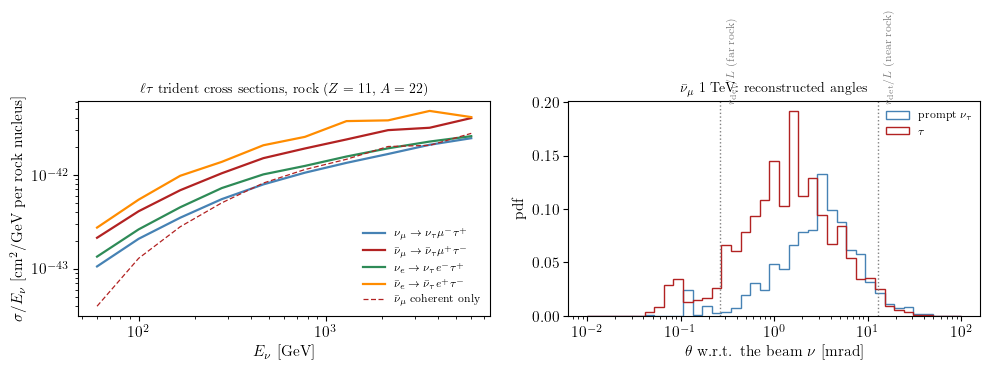

In [63]:
# cross sections on rock + closure of the four-vector reconstruction
import neptune as nep

fig, ax = plt.subplots(1, 2, figsize=(10, 3.8))
Etri = np.geomspace(60, 6000, 100)
tri_cols = {"numu": "steelblue", "numubar": "firebrick",
            "nue": "seagreen", "nuebar": "darkorange"}
tri_labs = {"numu": r"$\nu_\mu \to \nu_\tau\mu^-\tau^+$",
            "numubar": r"$\bar\nu_\mu \to \bar\nu_\tau\mu^+\tau^-$",
            "nue": r"$\nu_e \to \nu_\tau e^-\tau^+$",
            "nuebar": r"$\bar\nu_e \to \bar\nu_\tau e^+\tau^-$"}
for lab, c in tri_cols.items():
    ax[0].plot(Etri, nts.sigma_trident(Etri, lab) / Etri, color=c, lw=1.6,
               label=tri_labs[lab])
coh, dif = nts._trident_sigmas("numubar")
ax[0].plot(nts.TRIDENT_EG, coh / nts.TRIDENT_EG, color="firebrick", lw=0.9,
           ls=(0, (4, 2)), label=r"$\bar\nu_\mu$ coherent only")
ax[0].set_xscale("log")
ax[0].set_yscale("log")
ax[0].set_xlabel(r"$E_\nu$ [GeV]")
ax[0].set_ylabel(r"$\sigma/E_\nu$ [cm$^2$/GeV per rock nucleus]")
ax[0].legend(frameon=False, fontsize=8)
ax[0].set_title(r"$\ell\tau$ trident cross sections, rock ($Z=11$, $A=22$)",
                fontsize=10)

# closure: rebuild the invariants from the reconstructed four-vectors
gen = nep.TridentGenerator(nts._trident_model("numubar"), Z=nts.TRIDENT_Z_ROCK,
                           A=nts.TRIDENT_A_ROCK, Enu=1000.0, n_events=20_000,
                           nitn=4, neval=10_000, seed=1)
ev = {k: np.asarray(v) for k, v in gen.generate(verbose=False).items()}
vec = nts._trident_lab_kinematics(ev, 0.1056584, np.random.default_rng(0),
                                  return_vectors=True)
E, n_ev = ev["Enu"], len(ev["Enu"])
pnu = np.stack([np.zeros(n_ev), np.zeros(n_ev), E], 1)
qv = np.stack([vec["qT"], np.zeros(n_ev), vec["qz"]], 1)
dot = lambda a0, a, b0, b: a0 * b0 - np.sum(a * b, 1)
Ep, up = vec["E_nup"], vec["u_nup"]
resid = {
    r"$x_3 = q\cdot p_\tau$": dot(vec["q0"], qv, vec["E_tau"], vec["u_tau"]) / ev["x3"] - 1,
    r"$x_4 = q\cdot p_{\ell_1}$": dot(vec["q0"], qv, vec["E_l1"], vec["u_l1"]) / ev["x4"] - 1,
    r"$x_5 = p_\nu\cdot p_\tau$": dot(E, pnu, vec["E_tau"], vec["u_tau"]) / ev["x5"] - 1,
    r"$x_6 = p_\nu\cdot p_{\ell_1}$": dot(E, pnu, vec["E_l1"], vec["u_l1"]) / ev["x6"] - 1,
    r"$p_{\nu'}^2/W^2$": (Ep**2 - np.sum(up**2, 1)) / (2 * ev["x2"] - ev["x1"]),
}
for k, r in resid.items():
    print(f"closure {k:28s}: median |res| = {np.median(np.abs(r)):.2e}, "
          f"99% = {np.quantile(np.abs(r), 0.99):.2e}")

# reconstructed kinematics at the 1 TeV anchor (weighted events)
w_ev = ev["weight"]
th_np = np.arccos(np.clip(up[:, 2] / np.linalg.norm(up, axis=1), -1, 1))
th_ta = np.arccos(np.clip(vec["u_tau"][:, 2] / np.linalg.norm(vec["u_tau"], axis=1), -1, 1))
bins_th = np.geomspace(1e-2, 100, 40)
ax[1].hist(th_np * 1e3, bins=bins_th, weights=w_ev, histtype="step",
           color="steelblue", lw=1.6, density=True, label=r"prompt $\nu_\tau$")
ax[1].hist(th_ta * 1e3, bins=bins_th, weights=w_ev, histtype="step",
           color="firebrick", lw=1.6, density=True, label=r"$\tau$")
ax[1].axvline(DET_R / 4.8e5 * 1e3, color="gray", ls=":", lw=1.0)
ax[1].annotate(r"$r_{\rm det}/L$ (far rock)", xy=(DET_R / 4.8e5 * 1e3 * 1.15, 0.2),
               fontsize=8, color="gray", rotation=90)
ax[1].axvline(DET_R / 1e4 * 1e3, color="gray", ls=":", lw=1.0)
ax[1].annotate(r"$r_{\rm det}/L$ (near rock)", xy=(DET_R / 1e4 * 1e3 * 1.15, 0.2),
               fontsize=8, color="gray", rotation=90)
ax[1].set_xscale("log")
ax[1].set_xlabel(r"$\theta$ w.r.t. the beam $\nu$ [mrad]")
ax[1].set_ylabel("pdf")
ax[1].legend(frameon=False, fontsize=8)
ax[1].set_title(r"$\bar\nu_\mu$ 1 TeV: reconstructed angles", fontsize=10)
plt.tight_layout()
fig.savefig("plots/nutau_trident_validation.pdf", bbox_inches="tight", dpi=300)

In [64]:
# trident nu_tau fluxes: all four beam flavors, both detectors
tri = {}
for Ec_, W_, lab, det_lab in [(Ec_mub, W_mub, "numubar", "downstream"),
                              (Ec_nue, W_nue, "nue", "downstream"),
                              (Ec_mu, W_mu, "numu", "upstream"),
                              (Ec_eb, W_eb, "nuebar", "upstream")]:
    n_tri = (np.sum(W_ * nts.sigma_trident(Ec_, lab)) * rock.N
             / nts.TRIDENT_A_ROCK * (DIST - GAP - Lss_half))
    a, b = nts.nutau_flux_spectrum_trident_mc(Ec_, W_, lab, rock, Lss_half,
                                              DIST - GAP, DIST, DET_R,
                                              Enu_edges, n_mc=300_000, rng=21)
    tri[lab] = (a, b)
    print(f"{lab:8s} ({det_lab:10s}): {n_tri:.3e} tridents/yr in the rock | "
          f"through the face: prompt {a.sum():.3e} + tau-line {b.sum():.3e} /yr "
          f"| CC {events(a + b):.3f} /yr")

tri_p = sum(a + b for lab, (a, b) in tri.items() if lab in ("numubar", "nue"))
tri_m = sum(a + b for lab, (a, b) in tri.items() if lab in ("numu", "nuebar"))
tri_prompt = sum(a for a, b in tri.values())
tri_tau = sum(b for a, b in tri.values())
N_tri_p, N_tri_m = events(tri_p), events(tri_m)


numubar  (downstream): 3.906e+08 tridents/yr in the rock | through the face: prompt 3.986e+07 + tau-line 4.192e+07 /yr | CC 0.014 /yr
nue      (downstream): 2.121e+08 tridents/yr in the rock | through the face: prompt 3.056e+07 + tau-line 1.236e+07 /yr | CC 0.008 /yr
numu     (upstream  ): 2.361e+08 tridents/yr in the rock | through the face: prompt 3.186e+07 + tau-line 1.383e+07 /yr | CC 0.009 /yr
nuebar   (upstream  ): 4.502e+08 tridents/yr in the rock | through the face: prompt 4.792e+07 + tau-line 5.039e+07 /yr | CC 0.015 /yr


In [65]:
# MC ensemble for statistical uncertainty bands
n_rep = 6
n_mc_rep = 120_000

def _band_stats(samples):
        arr = np.asarray(samples)  # (n_rep, n_bins)
        return arr.mean(axis=0), arr.std(axis=0, ddof=1)

(
        charm_rep, charm_pr_rep, charm_tau_rep,
        itd3_rep, itd2_rep, res3_rep, res2_rep, tri_p_rep, tri_t_rep
) = ([] for _ in range(9))

for r in range(n_rep):
        seed = 1000 + r * 17

        # charm: split into prompt (Ds-line) and tau-line, plus total
        charm_pr = np.zeros_like(Enu_c)
        charm_tau = np.zeros_like(Enu_c)
        for i, (Ec_, W_, lab_) in enumerate([
                (Ec_mub, W_mub, "numubar"),
                (Ec_nue, W_nue, "nue"),
                (Ec_mu,  W_mu,  "numu"),
                (Ec_eb,  W_eb,  "nuebar"),
        ]):
                a, b = nts.nutau_flux_spectrum_mc(
                        Ec_, W_, lab_, rock, Lss_half, DIST - GAP, DIST, DET_R, Enu_edges,
                        n_mc=n_mc_rep, rng=seed + i
                )
                charm_pr += a
                charm_tau += b

        charm = charm_pr + charm_tau

        # ITD (upstream nuebar)
        i3, i2 = nts.nutau_flux_spectrum_itd_mc(
                Ec_eb, W_eb, rock, Lss_half, DIST - GAP, DIST, DET_R, Enu_edges,
                n_mc=n_mc_rep, rng=seed + 20
        )

        # Ds* resonance
        rr3, rr2 = nts.nutau_flux_spectrum_res_mc(
                E_eb_raw, w_eb_raw, rock, Lss_half, DIST - GAP, DIST, DET_R, Enu_edges,
                which="Ds*", n_mc=n_mc_rep, rng=seed + 30
        )

        # tridents (all 4 flavors)
        tp = np.zeros_like(Enu_c)
        tt = np.zeros_like(Enu_c)
        for j, (Ec_, W_, lab_) in enumerate([
                (Ec_mub, W_mub, "numubar"),
                (Ec_nue, W_nue, "nue"),
                (Ec_mu,  W_mu,  "numu"),
                (Ec_eb,  W_eb,  "nuebar"),
        ]):
                a, b = nts.nutau_flux_spectrum_trident_mc(
                        Ec_, W_, lab_, rock, Lss_half, DIST - GAP, DIST, DET_R, Enu_edges,
                        n_mc=n_mc_rep, rng=seed + 40 + j
                )
                tp += a
                tt += b

        charm_rep.append(charm / dE)
        charm_pr_rep.append(charm_pr / dE)
        charm_tau_rep.append(charm_tau / dE)
        itd3_rep.append(i3 / dE)
        itd2_rep.append(i2 / dE)
        res3_rep.append(rr3 / dE)
        res2_rep.append(rr2 / dE)
        tri_p_rep.append(tp / dE)
        tri_t_rep.append(tt / dE)

# mean + std bands
charm_mn, charm_sd = _band_stats(charm_rep)
charm_pr_mn, charm_pr_sd = _band_stats(charm_pr_rep)
charm_tau_mn, charm_tau_sd = _band_stats(charm_tau_rep)

itd3_mn, itd3_sd = _band_stats(itd3_rep)
itd2_mn, itd2_sd = _band_stats(itd2_rep)
res3_mn, res3_sd = _band_stats(res3_rep)
res2_mn, res2_sd = _band_stats(res2_rep)
tri_p_mn, tri_p_sd = _band_stats(tri_p_rep)
tri_t_mn, tri_t_sd = _band_stats(tri_t_rep)


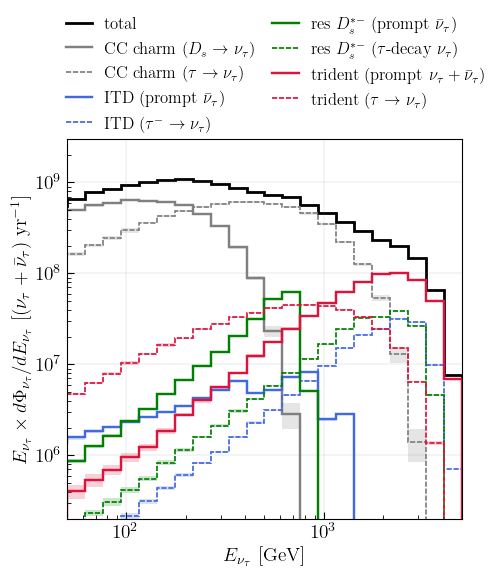

In [66]:
fig, ax = pt.std_fig(figsize=(5, 5))

def plot_with_band(y, yerr, color, label, lw=1.75, ls="-", z=2):
        lo = np.clip(y - yerr, 1e-30, None)  # keep positive for log axis
        hi = y + yerr
        ax.stairs(y*Enu_edges[:-1], Enu_edges, color=color, lw=lw, linestyle=ls, label=label, zorder=z)
        ax.fill_between(Enu_edges[:-1], Enu_edges[:-1]*lo, Enu_edges[:-1]*hi, step="post", color=color, alpha=0.20, linewidth=0, zorder=z-0.2)

# plot_with_band(charm_mn, charm_sd, "grey", r"CC charm", lw=2, z=1)
tot_rep = [
        charm_rep[i] + itd3_rep[i] + itd2_rep[i] + res3_rep[i] + res2_rep[i] + tri_p_rep[i] + tri_t_rep[i]
        for i in range(n_rep)
]
tot_mn, tot_sd = _band_stats(tot_rep)
plot_with_band(tot_mn, tot_sd, "black", r"total", lw=2, z=0.1)

plot_with_band(charm_pr_mn, charm_pr_sd, "grey", r"CC charm ($D_s \to \nu_\tau$)", z=1)
plot_with_band(charm_tau_mn, charm_tau_sd, "grey", r"CC charm ($\tau \to \nu_\tau$)", z=1, ls=(0, (3, 1)), lw=1.25)
plot_with_band(itd3_mn, itd3_sd, "royalblue", r"ITD (prompt $\bar\nu_\tau$)")
plot_with_band(itd2_mn, itd2_sd, "royalblue", r"ITD ($\tau^- \to \nu_\tau$)", ls=(0, (3, 1)), lw=1.25)
plot_with_band(res3_mn, res3_sd, "green", r"res $D_s^{*-}$ (prompt $\bar\nu_\tau$)")
plot_with_band(res2_mn, res2_sd, "green", r"res $D_s^{*-}$ ($\tau$-decay $\nu_\tau$)", ls=(0, (3, 1)), lw=1.25)
plot_with_band(tri_p_mn, tri_p_sd, "crimson", r"trident (prompt $\nu_\tau+\bar\nu_\tau$)")
plot_with_band(tri_t_mn, tri_t_sd, "crimson", r"trident ($\tau \to \nu_\tau$)", ls=(0, (3, 1)), lw=1.25)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(50, 5e3)
ax.set_ylim(2e3*1e2, 3e7*1e2)
ax.grid(which="major", ls="-", lw=0.25, color="gray", alpha=0.5)
ax.tick_params(which="minor", length=3, direction="in", labelsize=14)
ax.tick_params(which="major", length=5, direction="in", labelsize=14)
ax.tick_params(labelsize=14)
ax.set_xlabel(r"$E_{\nu_\tau}$ [GeV]", fontsize=14)
ax.set_ylabel(r"$E_{\nu_\tau}\times d\Phi_{\nu_\tau}/dE_{\nu_\tau}$ [$(\nu_\tau + \bar\nu_\tau)$ yr$^{-1}$]", fontsize=14)
ax.legend(frameon=False, fontsize=12, loc=(-0.02, 1.0), ncol=2, handlelength=1.6, handletextpad=0.7, columnspacing=1)

fig.savefig("plots/nutau_secondaries_spectrum_with_mc_band.pdf", bbox_inches="tight", dpi=400)

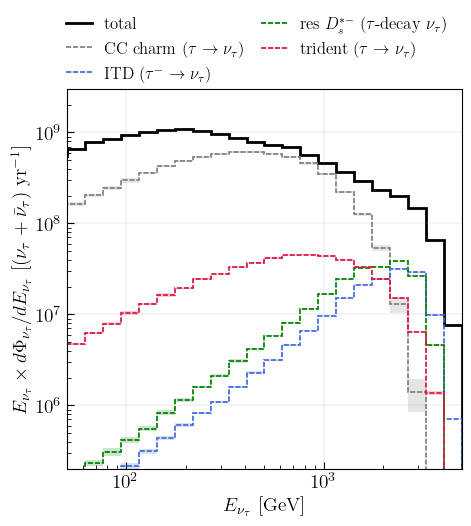

In [67]:
fig, ax = pt.std_fig(figsize=(5, 5))

def plot_with_band(y, yerr, color, label, lw=1.75, ls="-", z=2):
        lo = np.clip(y - yerr, 1e-30, None)  # keep positive for log axis
        hi = y + yerr
        ax.stairs(y*Enu_edges[:-1], Enu_edges, color=color, lw=lw, linestyle=ls, label=label, zorder=z)
        ax.fill_between(Enu_edges[:-1], Enu_edges[:-1]*lo, Enu_edges[:-1]*hi, step="post", color=color, alpha=0.20, linewidth=0, zorder=z-0.2)

# plot_with_band(charm_mn, charm_sd, "grey", r"CC charm", lw=2, z=1)
tot_rep = [
        charm_rep[i] + itd3_rep[i] + itd2_rep[i] + res3_rep[i] + res2_rep[i] + tri_p_rep[i] + tri_t_rep[i]
        for i in range(n_rep)
]
tot_mn, tot_sd = _band_stats(tot_rep)
plot_with_band(tot_mn, tot_sd, "black", r"total", lw=2, z=0.1)

# plot_with_band(charm_pr_mn, charm_pr_sd, "grey", r"CC charm ($D_s \to \nu_\tau$)", z=1)
plot_with_band(charm_tau_mn, charm_tau_sd, "grey", r"CC charm ($\tau \to \nu_\tau$)", z=1, ls=(0, (3, 1)), lw=1.25)
# plot_with_band(itd3_mn, itd3_sd, "royalblue", r"ITD (prompt $\bar\nu_\tau$)")
plot_with_band(itd2_mn, itd2_sd, "royalblue", r"ITD ($\tau^- \to \nu_\tau$)", ls=(0, (3, 1)), lw=1.25)
# plot_with_band(res3_mn, res3_sd, "green", r"res $D_s^{*-}$ (prompt $\bar\nu_\tau$)")
plot_with_band(res2_mn, res2_sd, "green", r"res $D_s^{*-}$ ($\tau$-decay $\nu_\tau$)", ls=(0, (3, 1)), lw=1.25)
# plot_with_band(tri_p_mn, tri_p_sd, "crimson", r"trident (prompt $\nu_\tau+\bar\nu_\tau$)")
plot_with_band(tri_t_mn, tri_t_sd, "crimson", r"trident ($\tau \to \nu_\tau$)", ls=(0, (3, 1)), lw=1.25)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(50, 5e3)
ax.set_ylim(2e3*1e2, 3e7*1e2)
ax.grid(which="major", ls="-", lw=0.25, color="gray", alpha=0.5)
ax.tick_params(which="minor", length=3, direction="in", labelsize=14)
ax.tick_params(which="major", length=5, direction="in", labelsize=14)
ax.tick_params(labelsize=14)
ax.set_xlabel(r"$E_{\nu_\tau}$ [GeV]", fontsize=14)
ax.set_ylabel(r"$E_{\nu_\tau}\times d\Phi_{\nu_\tau}/dE_{\nu_\tau}$ [$(\nu_\tau + \bar\nu_\tau)$ yr$^{-1}$]", fontsize=14)
ax.legend(frameon=False, fontsize=12, loc=(-0.02, 1.0), ncol=2, handlelength=1.6, handletextpad=0.7, columnspacing=1)

fig.savefig("plots/nutau_secondaries_spectrum_with_mc_band_tau.pdf", bbox_inches="tight", dpi=400)

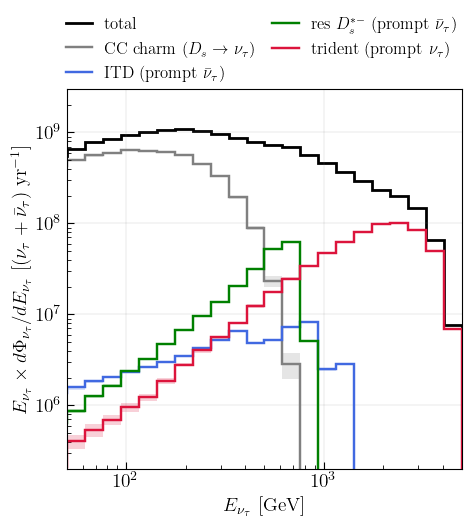

In [68]:
fig, ax = pt.std_fig(figsize=(5, 5))

def plot_with_band(y, yerr, color, label, lw=1.75, ls="-", z=2):
        lo = np.clip(y - yerr, 1e-30, None)  # keep positive for log axis
        hi = y + yerr
        ax.stairs(y*Enu_edges[:-1], Enu_edges, color=color, lw=lw, linestyle=ls, label=label, zorder=z)
        ax.fill_between(Enu_edges[:-1], Enu_edges[:-1]*lo, Enu_edges[:-1]*hi, step="post", color=color, alpha=0.20, linewidth=0, zorder=z-0.2)

# plot_with_band(charm_mn, charm_sd, "grey", r"CC charm", lw=2, z=1)
tot_rep = [
        charm_rep[i] + itd3_rep[i] + itd2_rep[i] + res3_rep[i] + res2_rep[i] + tri_p_rep[i] + tri_t_rep[i]
        for i in range(n_rep)
]
tot_mn, tot_sd = _band_stats(tot_rep)
plot_with_band(tot_mn, tot_sd, "black", r"total", lw=2, z=0.1)

plot_with_band(charm_pr_mn, charm_pr_sd, "grey", r"CC charm ($D_s \to \nu_\tau$)", z=1)
# plot_with_band(charm_tau_mn, charm_tau_sd, "grey", r"CC charm ($\tau \to \nu_\tau$)", z=1, ls=(0, (3, 1)), lw=1.25)
plot_with_band(itd3_mn, itd3_sd, "royalblue", r"ITD (prompt $\bar\nu_\tau$)")
# plot_with_band(itd2_mn, itd2_sd, "royalblue", r"ITD ($\tau^- \to \nu_\tau$)", ls=(0, (3, 1)), lw=1.25)
plot_with_band(res3_mn, res3_sd, "green", r"res $D_s^{*-}$ (prompt $\bar\nu_\tau$)")
# plot_with_band(res2_mn, res2_sd, "green", r"res $D_s^{*-}$ ($\tau$-decay $\nu_\tau$)", ls=(0, (3, 1)), lw=1.25)
plot_with_band(tri_p_mn, tri_p_sd, "crimson", r"trident (prompt $\nu_\tau$)")
# plot_with_band(tri_t_mn, tri_t_sd, "crimson", r"trident ($\tau \to \nu_\tau$)", ls=(0, (3, 1)), lw=1.25)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(50, 5e3)
ax.set_ylim(2e3*1e2, 3e7*1e2)
ax.grid(which="major", ls="-", lw=0.25, color="gray", alpha=0.5)
ax.tick_params(which="minor", length=3, direction="in", labelsize=14)
ax.tick_params(which="major", length=5, direction="in", labelsize=14)
ax.tick_params(labelsize=14)
ax.set_xlabel(r"$E_{\nu_\tau}$ [GeV]", fontsize=14)
ax.set_ylabel(r"$E_{\nu_\tau}\times d\Phi_{\nu_\tau}/dE_{\nu_\tau}$ [$(\nu_\tau + \bar\nu_\tau)$ yr$^{-1}$]", fontsize=14)
ax.legend(frameon=False, fontsize=12, loc=(-0.02, 1.0), ncol=2, handlelength=1.6, handletextpad=0.7, columnspacing=1)

fig.savefig("plots/nutau_secondaries_spectrum_with_mc_band_prompt.pdf", bbox_inches="tight", dpi=400)

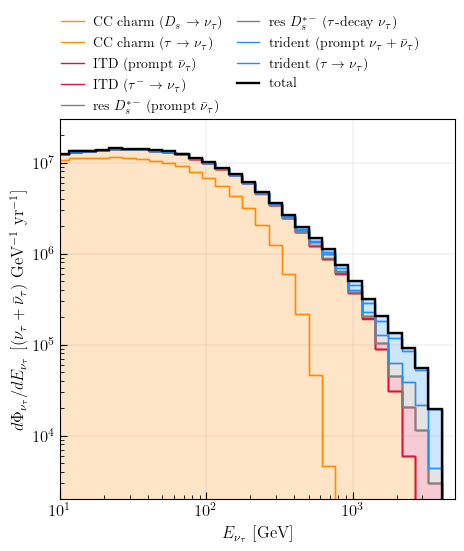

In [69]:
fig, ax = pt.std_fig(figsize=(5, 5))

# components to stack (all are already dPhi/dE arrays)
stack_components = [
    (charm_pr_mn, "darkorange", r"CC charm ($D_s \to \nu_\tau$)"),
    (charm_tau_mn, "darkorange", r"CC charm ($\tau \to \nu_\tau$)"),
    (itd3_mn, "crimson", r"ITD (prompt $\bar\nu_\tau$)"),
    (itd2_mn, "crimson", r"ITD ($\tau^- \to \nu_\tau$)"),
    (res3_mn, "grey", r"res $D_s^{*-}$ (prompt $\bar\nu_\tau$)"),
    (res2_mn, "grey", r"res $D_s^{*-}$ ($\tau$-decay $\nu_\tau$)"),
    (tri_p_mn, "dodgerblue", r"trident (prompt $\nu_\tau+\bar\nu_\tau$)"),
    (tri_t_mn, "dodgerblue", r"trident ($\tau \to \nu_\tau$)"),
]

cum = np.zeros_like(Enu_c, dtype=float)
for y, color, label in stack_components:
    y1 = cum
    y2 = cum + y
    ax.fill_between(Enu_edges[:-1], y1, y2, step="post", color=color, alpha=0.22, linewidth=0)
    ax.stairs(y2, Enu_edges, baseline=y1, color=color, lw=1.0, label=label)
    cum = y2

# total + MC band on top
tot_rep = [
    charm_rep[i] + itd3_rep[i] + itd2_rep[i] + res3_rep[i] + res2_rep[i] + tri_p_rep[i] + tri_t_rep[i]
    for i in range(n_rep)
]
tot_mn, tot_sd = _band_stats(tot_rep)
ax.fill_between(Enu_edges[:-1], np.clip(tot_mn - tot_sd, 1e-30, None), tot_mn + tot_sd,
                step="post", color="black", alpha=0.12, linewidth=0, zorder=5)
ax.stairs(tot_mn, Enu_edges, color="black", lw=1.7, label="total", zorder=6)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(10, 5e3)
ax.set_ylim(2e3, 3e7)
ax.grid(which="major", ls="-", lw=0.25, color="gray", alpha=0.5)
ax.tick_params(which="minor", length=3, direction="in")
ax.tick_params(which="major", length=5, direction="in")
ax.set_xlabel(r"$E_{\nu_\tau}$ [GeV]", fontsize=12)
ax.set_ylabel(r"$d\Phi_{\nu_\tau}/dE_{\nu_\tau}$ [$(\nu_\tau + \bar\nu_\tau)$ GeV$^{-1}$ yr$^{-1}$]", fontsize=12)
ax.legend(frameon=False, fontsize=10, loc=(-0.01, 1.0), ncol=2, handlelength=1.6, handletextpad=0.7, columnspacing=1)
ax.tick_params(labelsize=12)

fig.savefig("plots/nutau_secondaries_spectrum_stacked_with_mc_band.pdf", bbox_inches="tight", dpi=400)


trident nu_tau CC events/yr: downstream 0.022 | upstream 0.024
GRAND TOTAL with tridents (both detectors): 0.18 /yr


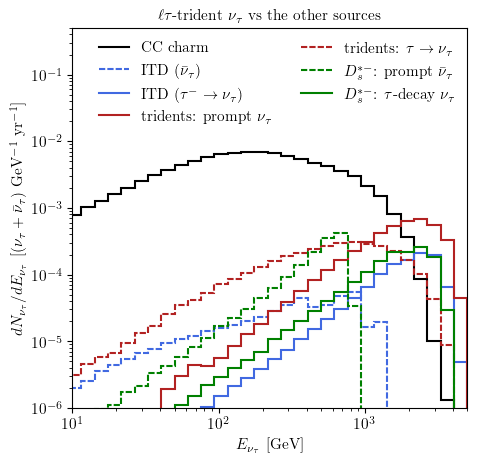

In [70]:
# "This flux" from the previous spectrum panel (same components you plotted there)
flux_this = (flux_mc + charm_m) + itd3 + itd2 + tri_prompt + tri_tau + sum(res["Ds*"])

# 1 kg/cm^2 detector column -> nucleon column [1/cm^2]
col_1kg = 1.0e3 / 1.66054e-24  # g/cm^2 divided by nucleon mass in g

# total cross section model: sigma / E_nu = 1e-38 cm^2/GeV  => sigma(E) = 1e-38 * E
sigma_tot = 1e-38 * Enu_c  # cm^2

# event spectrum
norm = sigma_tot * col_1kg


fig, ax = pt.std_fig(figsize=(5, 5))
ax.stairs((flux_mc + charm_m) / dE*norm, Enu_edges, color="black", lw=1.5,
          label=r"CC charm")
ax.stairs(itd3 / dE*norm, Enu_edges, color="royalblue", lw=1.5,  linestyle=(0, (3, 1)),
          label=r"ITD ($\bar\nu_\tau$)")
ax.stairs(itd2 / dE*norm, Enu_edges, color="royalblue", lw=1.5,
          label=r"ITD ($\tau^- \to \nu_\tau$)")
# ax.stairs(itd_tot / dE, Enu_edges, color="seagreen", lw=1.6,
#           label=r"inverse tau decay")
ax.stairs(tri_prompt / dE*norm, Enu_edges, color="firebrick", lw=1.5,
          label=r"tridents: prompt $\nu_\tau$")
ax.stairs(tri_tau / dE*norm, Enu_edges, color="firebrick", lw=1.5, linestyle=(0, (3, 1)),
          label=r"tridents: $\tau \to \nu_\tau$")


a, b = res["Ds*"]
ax.stairs(a / dE*norm, Enu_edges, color="green", lw=1.5, ls=(0, (3, 1)),
          label=r"$D_s^{*-}$: prompt $\bar\nu_\tau$")
ax.stairs(b / dE*norm, Enu_edges, color="green", lw=1.5,
          label=r"$D_s^{*-}$: $\tau$-decay $\nu_\tau$")
# ax.stairs(sum(res["D*"]) / dE, Enu_edges, color="darkorange", lw=1.2, ls=":",
        #   label=r"$D^{*-}$ (total)")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(10, 5e3)
ax.set_ylim(1e-6, 5e-1)
ax.set_xlabel(r"$E_{\nu_\tau}$ [GeV]")
ax.set_ylabel(r"$dN_{\nu_\tau}/dE_{\nu_\tau}$ [$(\nu_\tau + \bar\nu_\tau)$ GeV$^{-1}$ yr$^{-1}$]")
ax.set_title(r"$\ell\tau$-trident $\nu_\tau$ vs the other sources", fontsize=11)
ax.legend(frameon=False, fontsize=11, loc="upper right", ncol=2)
fig.savefig("plots/nutau_secondaries_spectrum.pdf", bbox_inches="tight", dpi=400)

print(f"\ntrident nu_tau CC events/yr: downstream {N_tri_p:.3f} | upstream {N_tri_m:.3f}")
N_grand = N_mc + N_charm_m + N_itd + N_res + N_tri_p + N_tri_m
print(f"GRAND TOTAL with tridents (both detectors): {N_grand:.2f} /yr")

nu_tau CC / yr (both detectors, col cancels in the ratio): 0.182
beam  CC / yr (both detectors):                            1.757e+09
integrated nu_tau CC per beam CC:                          1.04e-10
   CC charm                               6.43e-11
   ITD ($\tau^- \to \nu_\tau$)            5.15e-12
   ITD ($\bar\nu_\tau$)                   4.99e-13
   tridents: prompt $\nu_\tau$            1.93e-11
   tridents: $\tau \to \nu_\tau$          6.57e-12
   $D_s^{*-}$: $\tau$-decay $\nu_\tau$    6.04e-12
   $D_s^{*-}$: prompt $\bar\nu_\tau$      1.78e-12


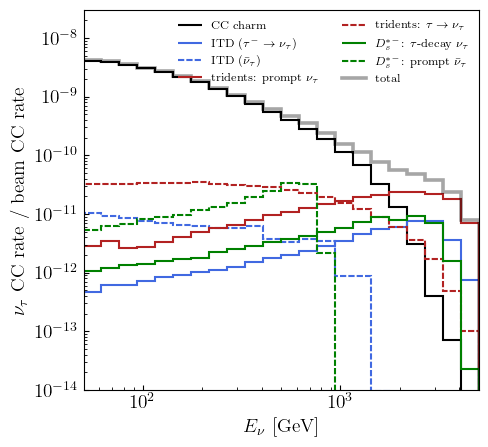

In [71]:
# ---------------------------------------------------------------------------
# nu_tau CC interactions PER beam-neutrino CC interaction, following the same
# logic as the wrong-sign ratio of notebook 3: numerator and denominator are
# both CC event spectra in the SAME signal volume, so the detector column
# density cancels exactly and the ratio is a property of the beam + rock
# rather than of the detector mass.
# ---------------------------------------------------------------------------

# Denominator: beam CC spectrum summed over the four flavors and both
# detectors, to match the scope of the nu_tau components above (which already
# include both beams). Use the RAW MC flux re-histogrammed onto Enu_edges --
# re-binning the `bin_flux` grid aliases into a castle-wall pattern (nb 3).
beam_cc = np.zeros_like(Enu_c)
beam_cc_by_side = {+1: np.zeros_like(Enu_c), -1: np.zeros_like(Enu_c)}
for s_, fl, side in [(sim, "numubar", +1), (sim_nue, "nue", +1),
                     (sim_numu, "numu", -1), (sim_nueb, "nuebar", -1)]:
    E_, w_, _ = det.flux_with_chords(s_, sign=side,
                                     exposure=injections_per_year)
    Wb = np.histogram(E_, bins=Enu_edges, weights=w_)[0]
    cc = Wb * xsecs.sigma_CC(Enu_c, fl) * det.cc_correction(Enu_c, fl)
    beam_cc += cc
    beam_cc_by_side[side] += cc

# Numerator: each nu_tau source folded with the tau-threshold-corrected CC
# cross section. sigma_nutau_cc_avg already averages nu_tau / nu_tau-bar.
sig_tau = nts.sigma_nutau_cc_avg(Enu_c)


def tau_over_beam(flux_binned):
    """nu_tau CC events per beam CC event, per energy bin."""
    return np.where(beam_cc > 0,
                    flux_binned * sig_tau / np.maximum(beam_cc, 1e-300),
                    np.nan)


COMPONENTS = [
    (flux_mc + charm_m, "black",      (0, ()),      r"CC charm"),
    (itd2,              "royalblue",  (0, ()),      r"ITD ($\tau^- \to \nu_\tau$)"),
    (itd3,              "royalblue",  (0, (3, 1)),  r"ITD ($\bar\nu_\tau$)"),
    (tri_prompt,        "firebrick",  (0, ()),      r"tridents: prompt $\nu_\tau$"),
    (tri_tau,           "firebrick",  (0, (3, 1)),  r"tridents: $\tau \to \nu_\tau$"),
    (res["Ds*"][1],     "green",      (0, ()),      r"$D_s^{*-}$: $\tau$-decay $\nu_\tau$"),
    (res["Ds*"][0],     "green",      (0, (3, 1)),  r"$D_s^{*-}$: prompt $\bar\nu_\tau$"),
]

fig, ax = pt.std_fig(figsize=(5, 5))
for f_, c_, ls_, lab_ in COMPONENTS:
    ax.stairs(tau_over_beam(f_), Enu_edges, color=c_, lw=1.5, ls=ls_, label=lab_)

flux_tau_tot = sum(f_ for f_, *_ in COMPONENTS)
ax.stairs(tau_over_beam(flux_tau_tot), Enu_edges, color="black", lw=2.6,
          alpha=0.35, label="total")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(50, 5000)
ax.set_ylim(1e-14, 3e-8)
ax.tick_params(axis="both", which="both", direction="in", labelsize=14)
ax.set_xlabel(r"$E_\nu$ [GeV]", fontsize=14)
ax.set_ylabel(r"$\nu_\tau$ CC rate / beam CC rate", fontsize=14)
ax.legend(frameon=False, fontsize=8.5, ncol=2, loc="upper right")
fig.savefig("plots/nutau_contamination.pdf", bbox_inches="tight", dpi=300)

# Integrated ratio, and the same split per detector for reference.
N_tau = float(np.sum(flux_tau_tot * sig_tau))
N_beam = float(np.sum(beam_cc))
print(f"nu_tau CC / yr (both detectors, col cancels in the ratio): "
      f"{N_tau * col_det:.3f}")
print(f"beam  CC / yr (both detectors):                            "
      f"{N_beam * col_det:.3e}")
print(f"integrated nu_tau CC per beam CC:                          "
      f"{N_tau / N_beam:.2e}")
for f_, _, _, lab_ in COMPONENTS:
    print(f"   {lab_:38s} {float(np.sum(f_ * sig_tau)) / N_beam:.2e}")

## 9. Baseline scan: 1-50 km

**Which detector is being moved?** The benchmark aperture is
$R = 2.5\,\sigma_{\rm spot} + z\tan(15\ {\rm mrad})$ with
$\sigma_{\rm spot}\propto D$, so a "benchmark detector at $D$" is a detector
*rebuilt* at each distance, growing in proportion and subtending a constant
solid angle. That is a different question from "where do I put the detector I
already have", and the two must not be mixed.

An earlier version of this scan did mix them -- it took the primary flux
through the growing aperture while passing the fixed 5 km radius to the
$\nu_\tau$ angular acceptance. The growing flux and the shrinking acceptance
cancelled, producing a **spuriously flat** curve. Neither consistent convention
is flat:

* **fixed 1.28 m** (the 5 km build, carried to each $D$): the rate **falls**,
  since the flux through a fixed face drops as the beam outgrows it while the
  rock column only grows linearly.
* **beam-matched** (rebuilt at each $D$): the rate **rises**, since the solid
  angle is held constant while the rock column grows -- but the aperture
  reaches 12.8 m radius at 50 km, which is not a detector anyone would build.

The solid black curve is the fixed-size convention, which is the meaningful
engineering comparison; the dotted curve is the beam-matched one for reference.
Both are now computed with a single radius used consistently for the flux and
the acceptance.

(Includes the resonant $D_s^{*-}$ source of Sec. 7 and the $\ell\tau$ tridents
of Sec. 8. $D^{*-}$ is negligible.)


In [72]:
D_scan = np.geomspace(0.5e5, 30e5, 9)   # 1 - 50 km

# ---------------------------------------------------------------------------
# WHICH DETECTOR is being moved? The benchmark aperture is defined as
# R = 2.5 sigma_spot + z tan(15 mrad) and sigma_spot ~ D, so a "benchmark
# detector at D" GROWS with D and subtends a constant solid angle. That is a
# perfectly good design statement, but it is a different question from "where
# do I put the detector I have". The two must not be mixed: the earlier version
# of this scan took the flux through the growing aperture while feeding the
# FIXED 5 km radius to the nu_tau angular acceptance, and the two errors
# cancelled into a spuriously flat curve.
#
#   fixed    : the 5 km detector (R = 1.28 m) carried to each D   -> rate falls
#   matched  : a detector rebuilt to the beam at each D           -> rate rises
# ---------------------------------------------------------------------------
R_FIXED = det.radius                                   # 1.28 m, the 5 km build

def R_matched(D):
    return det.radius * D / det.dist                   # beam-matched aperture

def face_flux_raw(s, D, sign=+1, r_sel=None):
    E_, w_, *_ = det.face_rays(s, sign=sign, exposure=injections_per_year,
                               dist=D, r_sel=R_FIXED if r_sel is None else r_sel)
    return E_, w_

def face_flux(s, D, sign=+1, r_sel=None):
    return dt.bin_flux(*face_flux_raw(s, D, sign, r_sel))


def run_scan(R_of, sims_d=None, rng0=7, n_mc=150_000):
    """nu_tau CC events/yr per source vs D, with ONE radius convention used
    consistently for both the primary flux and the nu_tau acceptance."""
    sd = sims if sims_d is None else sims_d
    s_p, s_e, s_m, s_eb = (sd["numubar"], sd["nue"], sd["numu"], sd["nuebar"])
    out = {"charm_p": [], "charm_m": [], "itd": [], "res": [], "tri": []}
    for D in D_scan:
        R = R_of(D)
        tot = 0.0
        for s_, lab in [(s_p, "numubar"), (s_e, "nue")]:
            Ec_, W_ = face_flux(s_, D, +1, R)
            a, b = nts.nutau_flux_spectrum_mc(Ec_, W_, lab, rock, Lss_half,
                                              D - GAP, D, R, Enu_edges,
                                              n_mc=n_mc, rng=rng0)
            tot += events(a + b)
        out["charm_p"].append(tot)

        tot = 0.0
        for s_, lab in [(s_m, "numu"), (s_eb, "nuebar")]:
            Ec_, W_ = face_flux(s_, D, -1, R)
            a, b = nts.nutau_flux_spectrum_mc(Ec_, W_, lab, rock, Lss_half,
                                              D - GAP, D, R, Enu_edges,
                                              n_mc=n_mc, rng=rng0 + 1)
            tot += events(a + b)
        out["charm_m"].append(tot)

        Ec_, W_ = face_flux(s_eb, D, -1, R)
        a, b = nts.nutau_flux_spectrum_itd_mc(Ec_, W_, rock, Lss_half, D - GAP,
                                              D, R, Enu_edges, n_mc=n_mc,
                                              rng=rng0 + 2)
        out["itd"].append(events(a + b))

        Er, wr = face_flux_raw(s_eb, D, -1, R)
        a, b = nts.nutau_flux_spectrum_res_mc(Er, wr, rock, Lss_half, D - GAP,
                                              D, R, Enu_edges, which="Ds*",
                                              n_mc=100_000, rng=rng0 + 3)
        out["res"].append(events(a + b))

        tot = 0.0
        for s_, lab, sg in [(s_p, "numubar", +1), (s_e, "nue", +1),
                            (s_m, "numu", -1), (s_eb, "nuebar", -1)]:
            Ec_, W_ = face_flux(s_, D, sg, R)
            a, b = nts.nutau_flux_spectrum_trident_mc(Ec_, W_, lab, rock,
                                                      Lss_half, D - GAP, D, R,
                                                      Enu_edges, n_mc=100_000,
                                                      rng=rng0 + 4)
            tot += events(a + b)
        out["tri"].append(tot)
    return {k: np.array(v) for k, v in out.items()}


scan = run_scan(lambda D: R_FIXED, rng0=7)
scan_matched = run_scan(R_matched, rng0=17)
total = sum(scan[k] for k in scan)
total_matched = sum(scan_matched[k] for k in scan_matched)
print(f"{'D [km]':>8s}{'fixed 1.28 m':>15s}{'beam-matched':>15s}{'R_matched [m]':>15s}")
for i, D in enumerate(D_scan):
    print(f"{D/1e5:8.1f}{total[i]:15.3f}{total_matched[i]:15.3f}"
          f"{R_matched(D)/100:15.2f}")


  D [km]   fixed 1.28 m   beam-matched  R_matched [m]
     0.5          0.084          0.011           0.13
     0.8          0.133          0.022           0.21
     1.4          0.159          0.039           0.36
     2.3          0.168          0.068           0.59
     3.9          0.165          0.115           0.99
     6.5          0.130          0.195           1.65
    10.8          0.075          0.331           2.75
    18.0          0.036          0.554           4.59
    30.0          0.014          0.919           7.67


fixed 1.28 m detector: best baseline D = 2.3 km, 0.17 events/yr
  1 km -> 50 km: 0.084 -> 0.014 events/yr (x0.17)
beam-matched detector: 0.011 -> 0.919 events/yr (x82.02), but the aperture grows to 7.7 m


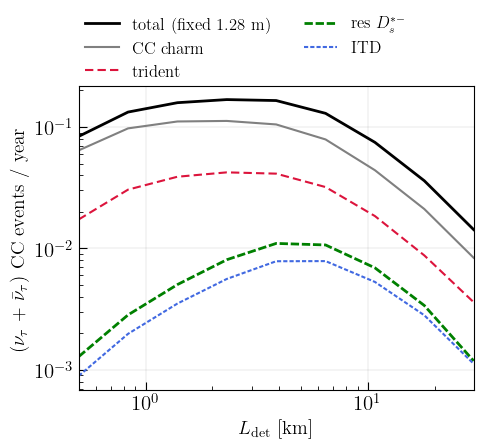

In [73]:
fig, ax = pt.std_fig(figsize=(5, 4))
Dkm = D_scan / 1e5

ax.plot(Dkm, total, "-", color="black", lw=2.0, label="total (fixed 1.28 m)")
# ax.plot(Dkm, total_matched, "-", color="black", lw=1.4, ls=(0, (1, 1)),
        # label="total (beam-matched)")
ax.plot(Dkm, scan["charm_p"] + scan["charm_m"], color="grey", lw=1.5,
        label=r"CC charm")
ax.plot(Dkm, scan["tri"], color="crimson", lw=1.5, ls=(0, (4, 2)),
        label=r"trident")
ax.plot(Dkm, scan["res"], color="green", lw=2, ls=(0, (3, 1)),
        label=r"res $D_s^{*-}$")
ax.plot(Dkm, scan["itd"], color="royalblue", lw=1.5, ls=(0, (2, 1)),
        label="ITD")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(0.5, 30)
ax.set_xlabel(r"$L_{\rm det}$ [km]", fontsize=14)
ax.set_ylabel(r"($\nu_\tau$ + $\bar\nu_\tau$) CC events / year", fontsize=14)
ax.legend(frameon=False, fontsize=12, loc=(0, 1.0), ncol=2)
ax.grid(which="major", ls="-", lw=0.25, color="gray", alpha=0.5)
ax.tick_params(which="minor", length=3, direction="in")
ax.tick_params(which="major", length=6, direction="in")
ax.tick_params(labelsize=15)

fig.savefig("plots/nutau_baseline_scan.pdf", bbox_inches="tight", dpi=300)

i_b = int(np.argmax(total))
print(f"fixed 1.28 m detector: best baseline D = {Dkm[i_b]:.1f} km, "
      f"{total[i_b]:.2f} events/yr")
print(f"  1 km -> 50 km: {total[0]:.3f} -> {total[-1]:.3f} events/yr "
      f"(x{total[-1]/total[0]:.2f})")
print(f"beam-matched detector: {total_matched[0]:.3f} -> {total_matched[-1]:.3f} "
      f"events/yr (x{total_matched[-1]/total_matched[0]:.2f}), but the aperture "
      f"grows to {R_matched(D_scan[-1])/100:.1f} m")


### Beam dynamics off

The same 5 km spectrum and 1–50 km scan with `beam_dynamics=False` (ideal
closed orbit, nominal momentum: no beam divergence/size, no $\Delta p/p$, no
dispersion). The comparison isolates what the accelerator optics does to the
secondary-$\nu_\tau$ rates: the $\sim$0.6 mrad IP divergence broadens the
primary beam spot, feeding the acceptance at small baselines and starving it
at large ones. Figures saved with the `_nobd` suffix.

In [74]:
# regenerate the four primary fluxes with beam dynamics off, then reuse the
# SAME run_scan as above -- previously this cell carried a second, copy-pasted
# implementation of the whole scan, which is exactly how the two drifted apart.
_, sims_nb, _ = mint.examples.both_beams(beam_dynamics=False)

scan_nb = run_scan(lambda D: R_FIXED, sims_d=sims_nb, rng0=40)
total_nb = sum(scan_nb[k] for k in scan_nb)
print(f"{'D [km]':>8s}{'beam dyn ON':>14s}{'beam dyn OFF':>14s}{'ratio':>9s}")
for i, D in enumerate(D_scan):
    print(f"{D/1e5:8.1f}{total[i]:14.3f}{total_nb[i]:14.3f}"
          f"{total_nb[i]/max(total[i], 1e-30):9.2f}")


/Users/mhostert/Repos/MINT/mint/MuC.py:442: UserWarning: The lattice covers only 14.6% of the machine (arc length 1.465e+05 cm of total_circumference 1e+06 cm). Muon decays are placed on the covered section only; muon travel times account for propagation through the full machine.
  warnings.warn(


  D [km]   beam dyn ON  beam dyn OFF    ratio
     0.5         0.084         0.084     1.01
     0.8         0.133         0.136     1.02
     1.4         0.159         0.172     1.08
     2.3         0.168         0.197     1.17
     3.9         0.165         0.216     1.31
     6.5         0.130         0.230     1.78
    10.8         0.075         0.241     3.23
    18.0         0.036         0.246     6.82
    30.0         0.014         0.250    17.54


## 10. Notes

- The chain normalization ($f_{D_s} \times {\rm BR} = 4.3\times 10^{-3}$ per charm CC)
  and $\sigma_{\rm charm}$ are solid; the energy kernels and especially the
  **$p_T^{\rm eff}$ cone** are the rough parts — vary `PT_EFF` (0.5–1 GeV) for a spread.
- The dominant component is the **$\tau$-decay line** (harder, more collinear);
  the soft $D_s$-line neutrinos mostly miss the detector from far upstream.
- The **$\ell\tau$ tridents** (Sec. 8) are the second-largest source: all four
  beam flavors contribute, the exact NEPTUNE kinematics make the accepted
  spectrum hard (the prompt $\nu_\tau$ takes $\sim$half the beam energy), and
  the coherent $Z^2$ enhancement partly compensates the small per-nucleon rate.
- With this small detector the rate is $\mathcal{O}(1)$/yr; a denser fiducial
  (e.g. 10 m of iron instead of gas: $\times 25$ column) or the $\mu^-$ beam
  ($\times 2$) brings tens of $\tau$-appearance events per year — a genuine
  secondary-$\nu_\tau$ beam, with the $\nu_\tau$ direction tagged to $\sim$mrad.